# Master's Thesis
Name: Marc Pham  
Advisor: Sanjaya Lohani

In [31]:
import sys
import time
import random
import numpy as np
from functools import partial
import matplotlib.pyplot as plt
import pennylane as qp

In [4]:
# Installation Cell
!{sys.executable} -m pip install --upgrade pip
!{sys.executable} -m pip install pennylane
!{sys.executable} -m pip install matplotlib

In [6]:
# Version Verification Cell
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("PennyLane:", qp.__version__)

Python: 3.12.2
NumPy: 2.5.3
PennyLane: 0.45.1


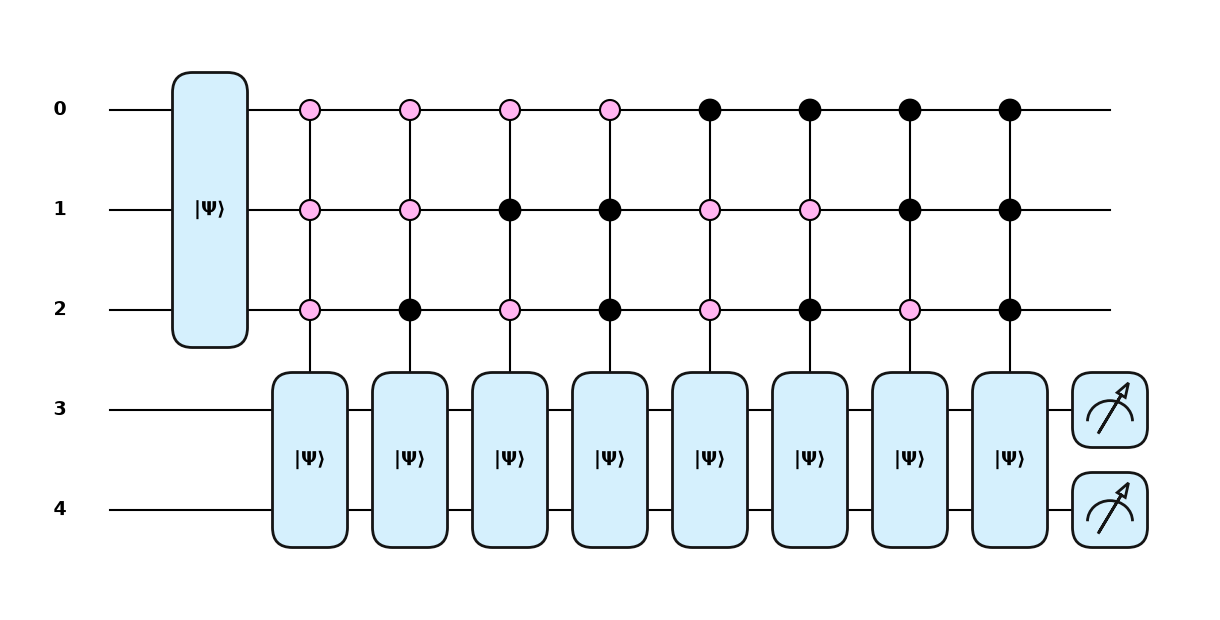

Elapsed time: 0.622325 s


In [9]:
start = time.perf_counter()

bitstrings = ["01", "11", "11", "00", "01", "11", "11", "00"]

control_wires = [0, 1, 2]
target_wires = [3, 4]

Ui = [qp.BasisState(int(bitstring, 2), target_wires) for bitstring in bitstrings]

dev = qp.device("default.qubit")


# This line is included for drawing purposes only.
@partial(qp.transforms.decompose, max_expansion=1)
@qp.set_shots(1)
@qp.qnode(dev)
def circuit(index):
    qp.BasisState(index, wires=control_wires)
    qp.Select(Ui, control=control_wires)
    return qp.sample(wires=target_wires)


qp.draw_mpl(circuit, style="pennylane")(3)
plt.show()

elapsed = time.perf_counter() - start
print(f"Elapsed time: {elapsed:.6f} s")

In [21]:
bitstrings = ["01", "11", "11", "00", "01", "11", "11", "00"]

control_wires = [0, 1, 2]
target_wires = [3, 4]


@partial(qp.compile, basis_set="CNOT")  # Line added for resource estimation purposes only.
@qp.set_shots(1)
@qp.qnode(dev)
def circuit(index):
    qp.BasisState(index, wires=control_wires)
    qp.QROM(bitstrings, control_wires, target_wires, work_wires=None)
    return qp.sample(wires=target_wires)


for i in range(8):
    print(f"The bitstring stored in index {i} is: {circuit(i)[0]}")

The bitstring stored in index 0 is: [0 1]
The bitstring stored in index 1 is: [1 1]
The bitstring stored in index 2 is: [1 1]
The bitstring stored in index 3 is: [0 0]
The bitstring stored in index 4 is: [0 1]
The bitstring stored in index 5 is: [1 1]
The bitstring stored in index 6 is: [1 1]
The bitstring stored in index 7 is: [0 0]


In [12]:
print("Number of qubits: ", len(control_wires + target_wires))
print("One-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[1])
print("Two-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[2])

Number of qubits:  5
One-qubit gates:  495
Two-qubit gates:  240


In [15]:
print("Number of qubits: ", len(control_wires + target_wires))
print("One-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[1])
print("Two-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[2])

Number of qubits:  6
One-qubit gates:  496
Two-qubit gates:  240


In [22]:
print("Number of qubits: ", len(control_wires + target_wires))
print("One-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[1])
print("Two-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[2])

Number of qubits:  5
One-qubit gates:  495
Two-qubit gates:  240


In [20]:
bitstrings = ["01", "11", "11", "00", "01", "11", "11", "00"]

control_wires = [0, 1, 2]
target_wires = [3, 4]
work_wires = [5, 6]


@partial(qp.compile, basis_set="CNOT")
@qp.set_shots(1)
@qp.qnode(dev)
def circuit(index):
    qp.BasisState(index, wires=control_wires)
    #  added work wires below
    qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
    return qp.sample(wires=control_wires + target_wires + work_wires)

print("Number of qubits: ", len(control_wires + target_wires + work_wires))
print("One-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[1])
print("Two-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[2])

Number of qubits:  7
One-qubit gates:  155
Two-qubit gates:  76


In [18]:
bitstrings = ["01", "11", "11", "00", "01", "11", "11", "00"]

control_wires = [0, 1, 2]
target_wires = [3, 4]
work_wires = [5, 6]


@partial(qp.compile, basis_set="CNOT")  # Line added for resource estimation purposes only.
@qp.set_shots(1)
@qp.qnode(dev)
def circuit(index):
    qp.BasisState(index, wires=control_wires)
    qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=True)
    return qp.sample(wires=target_wires + work_wires)


for i in range(8):
    print(f"The bitstring stored in index {i} is: {circuit(i)[0, :2]}")
    print(f"The work wires for that index are in the state: {circuit(i)[0, 2:4]}\n")

The bitstring stored in index 0 is: [0 1]
The work wires for that index are in the state: [0 0]

The bitstring stored in index 1 is: [1 1]
The work wires for that index are in the state: [0 0]

The bitstring stored in index 2 is: [1 1]
The work wires for that index are in the state: [0 0]

The bitstring stored in index 3 is: [0 0]
The work wires for that index are in the state: [0 0]

The bitstring stored in index 4 is: [0 1]
The work wires for that index are in the state: [0 0]

The bitstring stored in index 5 is: [1 1]
The work wires for that index are in the state: [0 0]

The bitstring stored in index 6 is: [1 1]
The work wires for that index are in the state: [0 0]

The bitstring stored in index 7 is: [0 0]
The work wires for that index are in the state: [0 0]



In [19]:
print("Number of qubits: ", len(control_wires + target_wires))
print("One-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[1])
print("Two-qubit gates: ", qp.specs(circuit)(0)["resources"].gate_sizes[2])

Number of qubits:  5
One-qubit gates:  368
Two-qubit gates:  184


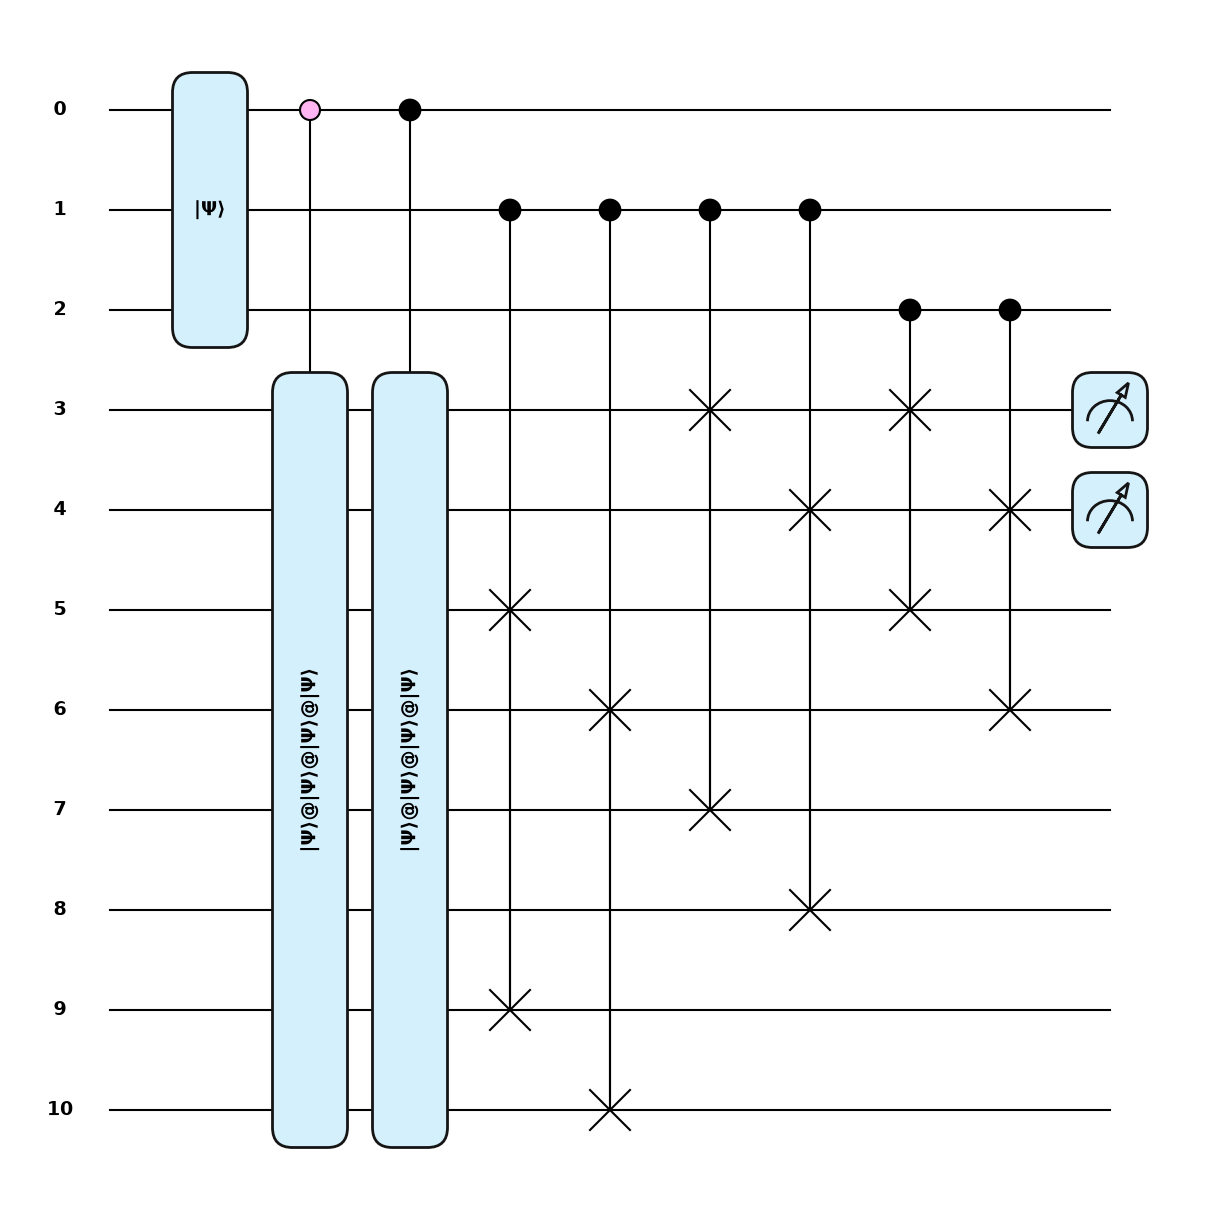

In [23]:
bitstrings = ["01", "11", "11", "00", "01", "11", "11", "00"]

control_wires = [0, 1, 2]
target_wires = [3, 4]
work_wires = [5, 6, 7, 8, 9, 10, 11, 12]


# Line added for drawing purposes only
@partial(qp.transforms.decompose, max_expansion=2)
@qp.set_shots(1)
@qp.qnode(qp.device("default.qubit"))
def circuit(index):
    qp.BasisState(index, wires=control_wires)
    qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
    return qp.sample(wires=target_wires), qp.sample(wires=target_wires)

qp.draw_mpl(circuit, style="pennylane")(0)
plt.show()

In [24]:
(0.99)**20

0.8179069375972308

In [26]:
0.998**40

0.9230424014270334

In [27]:
# Estimated fidelity
fidelity = (
    (0.9995)**num_1q *
    (0.99)**num_2q
)

### Preliminary Observations:
- clean = True adds many more one and two qubit gates when using work_wires.
- Need to do some more research on how many work wires added exactly when we increase the number of swaps.
- The circuit function will ignore any work wires that aren't needed, so the specified number doesn't exactly match what is shown.
- The counting function for the number of gates is very fast, so we can try to generate a graph of one-qubit and two-qubit gates.
- Cost function also needs to account for the number of qubits being added with the work lines, if that even matters because we only use them for temporary swapping. Apparently, more qubits = more susceptible to idle errors.
- Still need to dissect the number of gates reported with logically determining how that number came to be.
- Do research on the average gate fidelity for 1Q vs. 2Q gates and determine how close that gets to the simulated value.
- **bucket brigade / SelectSwapQROM style decomposition** makes it so we only need 3 pairs of swaps instead of 2^3, so do more research on this.
- Next Steps: Find the best way to vary the number of control vs. work wires

Only L = 1,3,7,15 generate different circuits for N = 16. Likely $\log_2(N)-1$. Please find a way to describe the variable based on how the article describes it.

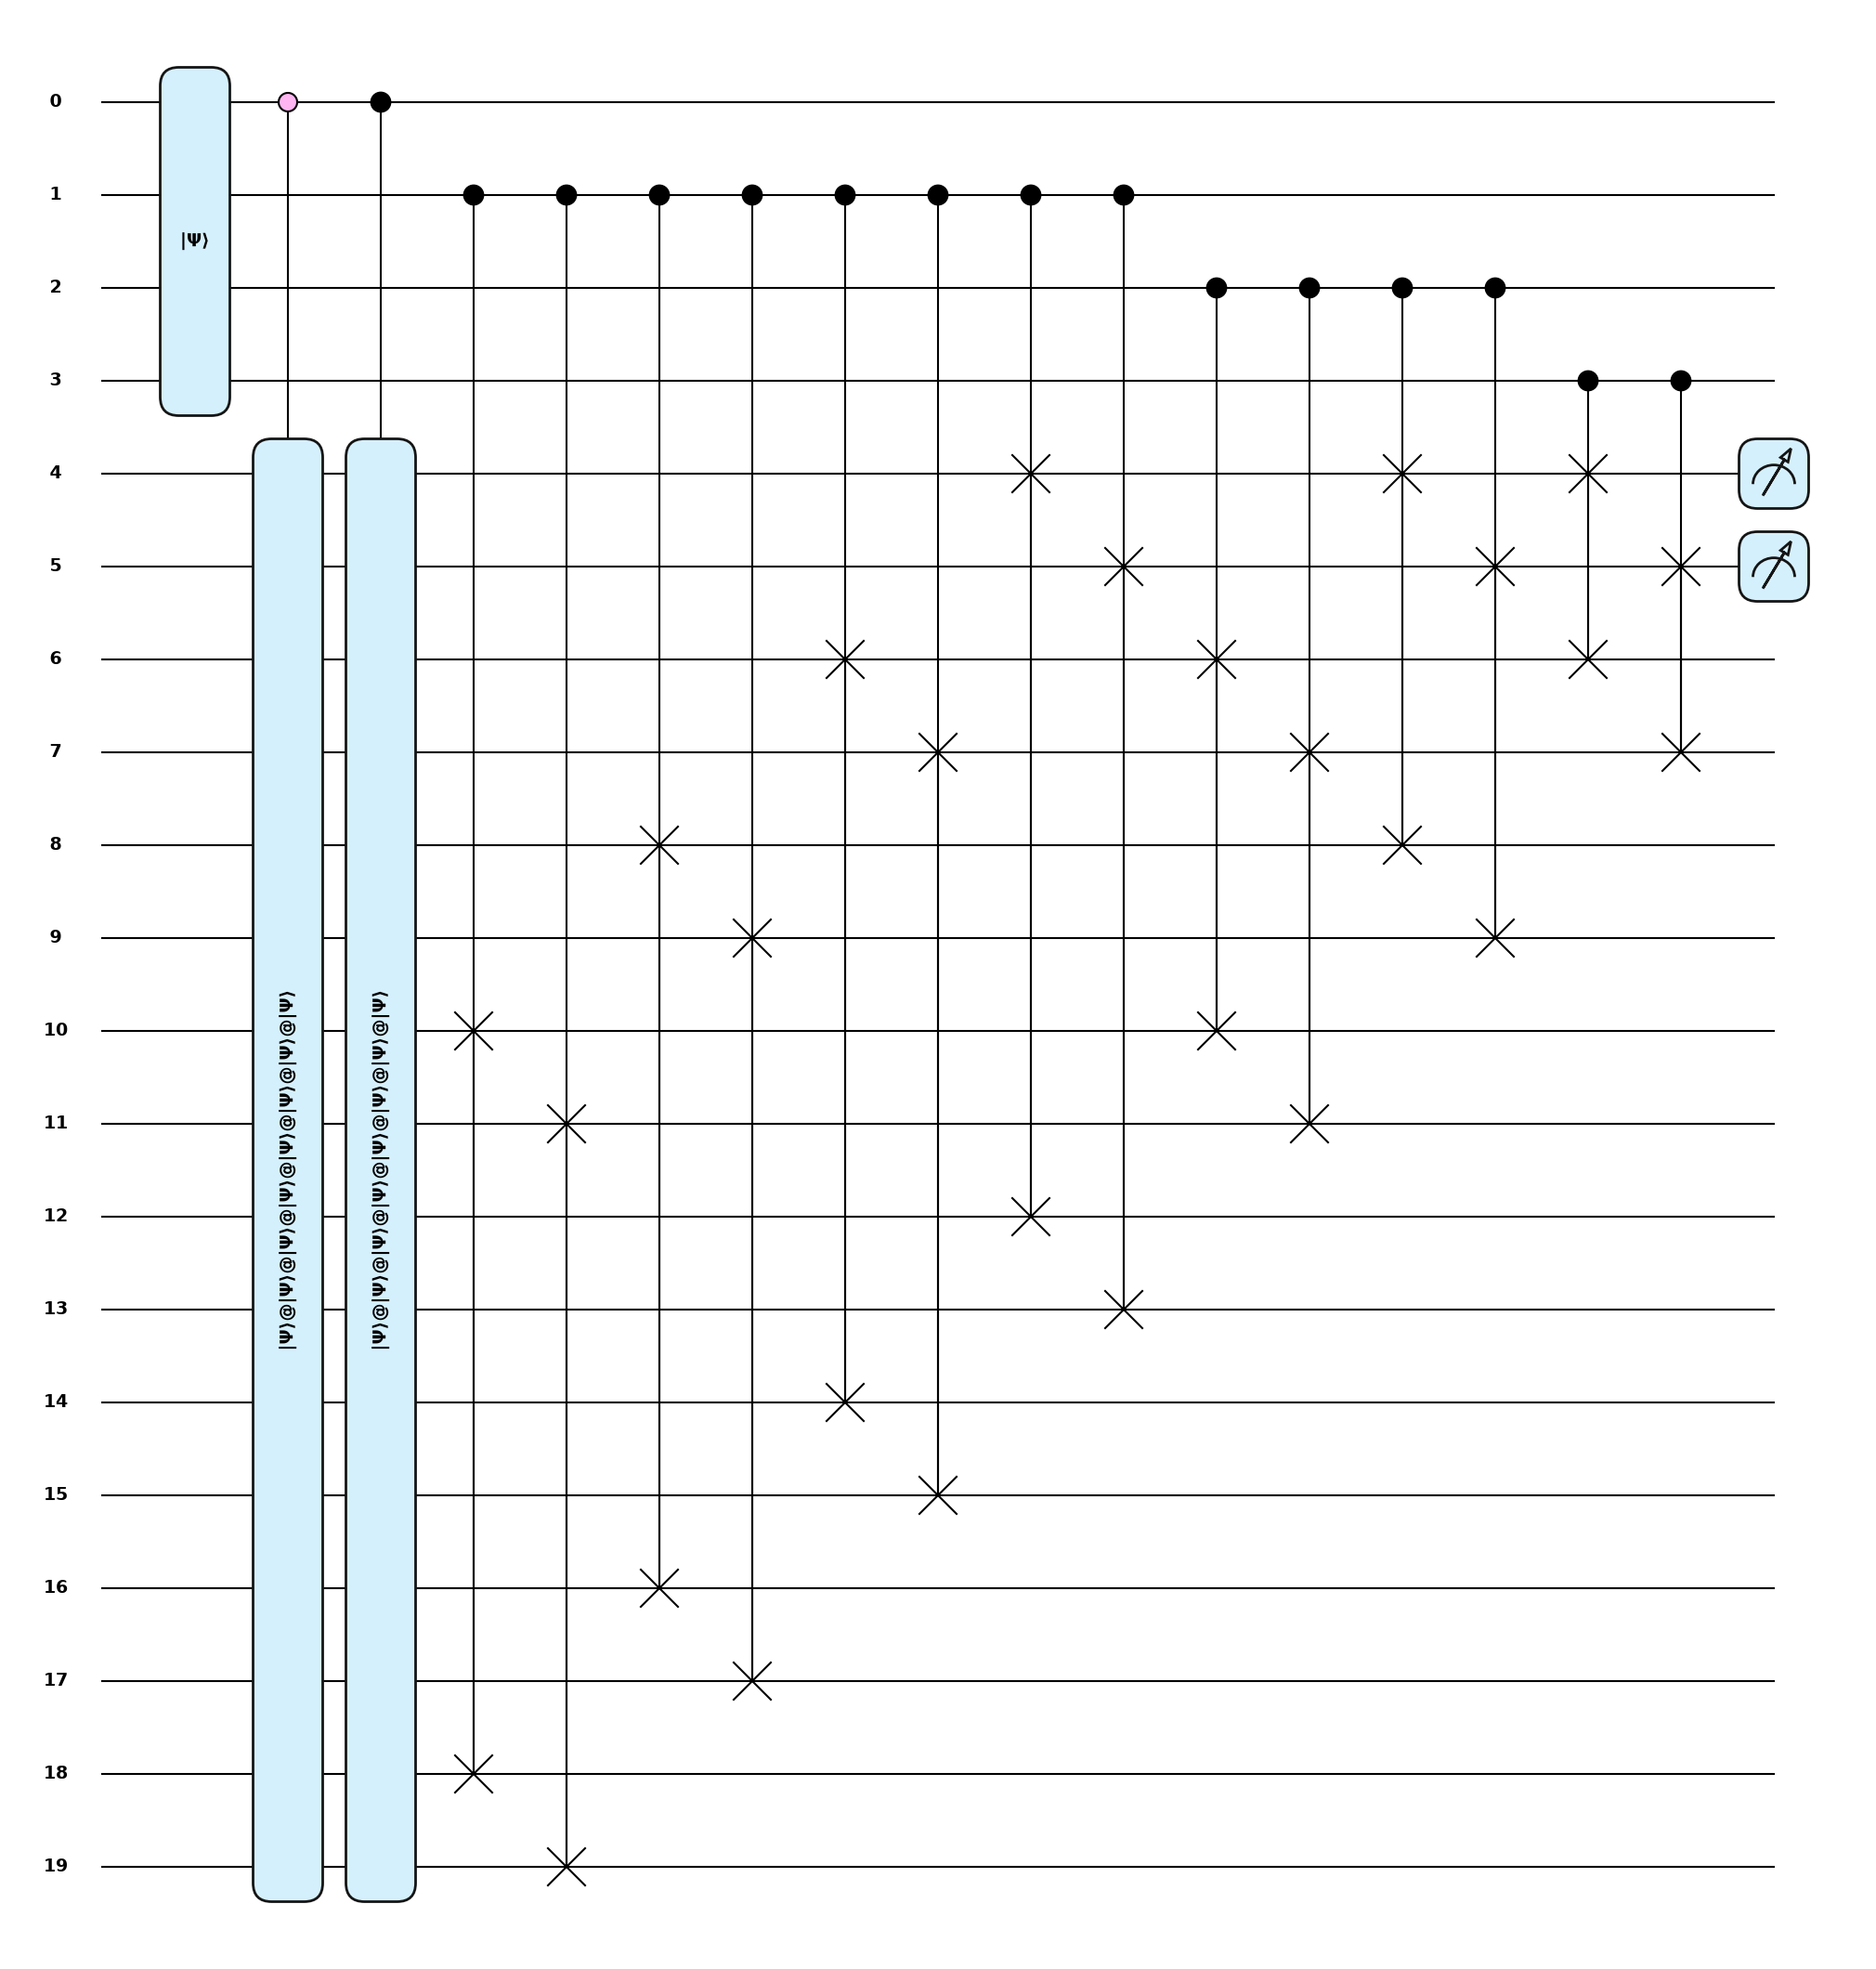

In [68]:
QROM_size = 16
L = 14          # Different L = 1,3,7,15 that matter are log2(N) - 1
bit_len = 2

def generate_bitstrings(array_length, bit_length):
    return [f"{random.randint(0, 3):0{bit_length}b}" for _ in range(array_length)]

bitstrings = generate_bitstrings(QROM_size, bit_len)

num_ctrl      = int(np.ceil(np.log2(QROM_size)))
control_wires = np.arange(num_ctrl)
target_wires  = np.arange(num_ctrl, num_ctrl + 2)
work_wires    = np.arange(target_wires[-1] + 1, target_wires[-1] + 1 + L*bit_len)

# Line added for drawing purposes only
@partial(qp.transforms.decompose, max_expansion=2)
@qp.set_shots(1)
@qp.qnode(qp.device("default.qubit"))
def circuit(index):
    qp.BasisState(index, wires=control_wires)
    qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
    return qp.sample(wires=target_wires), qp.sample(wires=target_wires)

qp.draw_mpl(circuit, style="pennylane")(0)
plt.show()

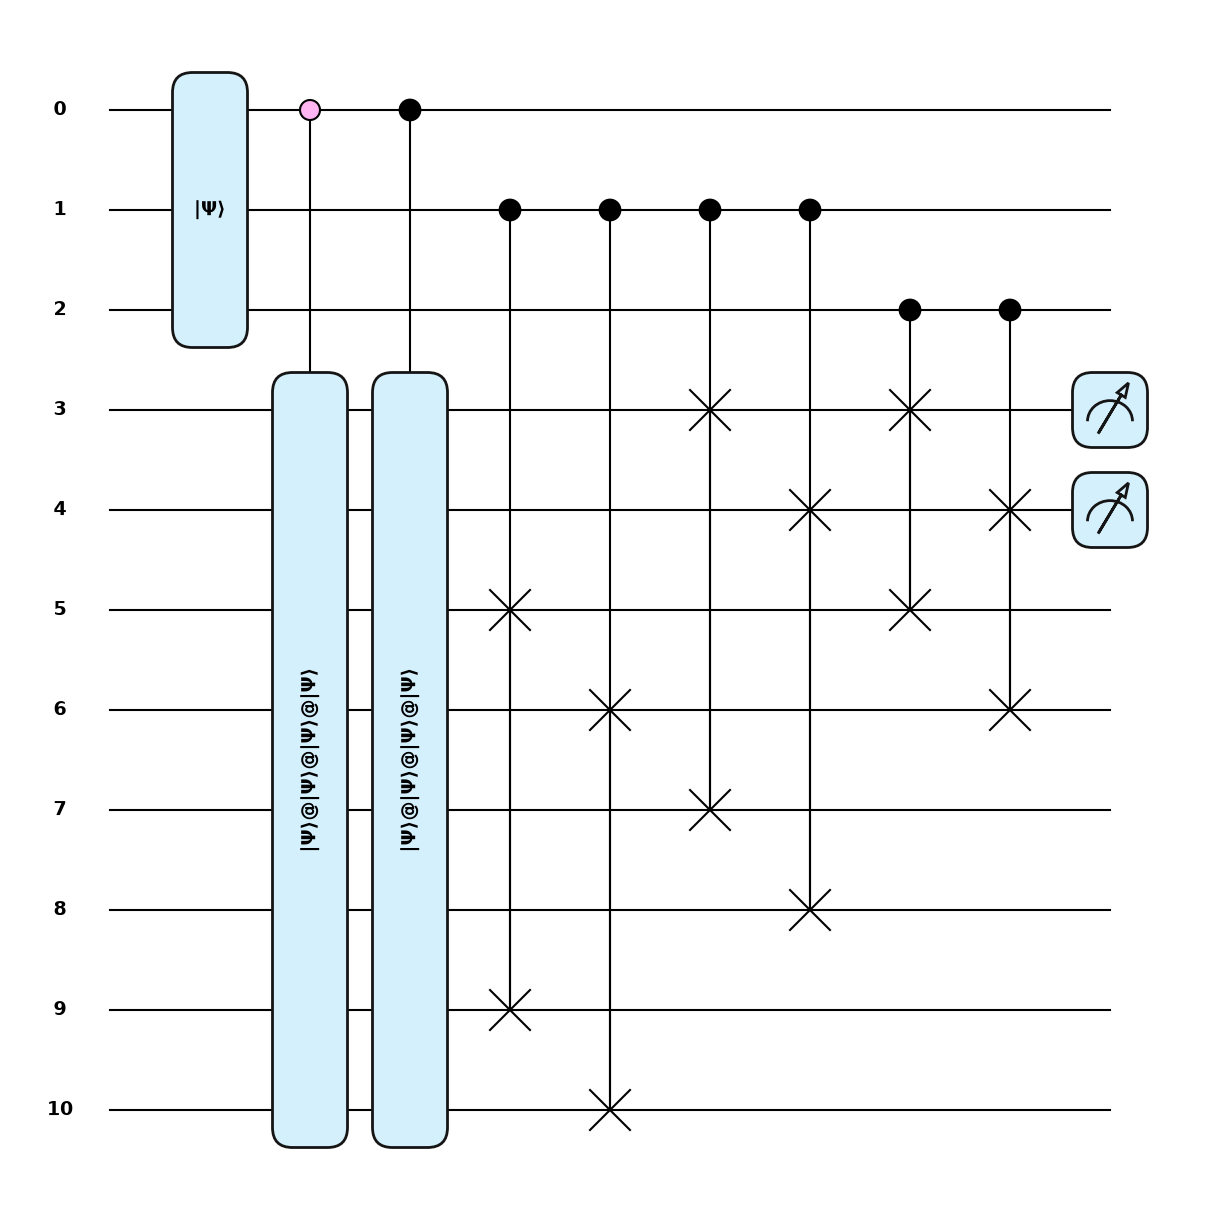

In [47]:
bitstrings = ["01", "11", "11", "00", "01", "11", "11", "00"]

control_wires = [0, 1, 2]
target_wires = [3, 4]
work_wires = [5, 6, 7, 8, 9, 10, 11, 12]


# Line added for drawing purposes only
@partial(qp.transforms.decompose, max_expansion=2)
@qp.set_shots(1)
@qp.qnode(qp.device("default.qubit"))
def circuit(index):
    qp.BasisState(index, wires=control_wires)
    qp.QROM(bitstrings, control_wires, target_wires, work_wires, clean=False)
    return qp.sample(wires=target_wires), qp.sample(wires=target_wires)

qp.draw_mpl(circuit, style="pennylane")(0)
plt.show()